In [21]:
L = 6
B = 5
T = 0.3
A = L*B
concrete_volume = A*T

col_offset_x = 0.0  # column offset from footing centroid in X (m)
col_offset_y = 0.0  # column offset from footing centroid in Y (m)

# Concrete properties
gamma_concrete = 2400  # unit weight of concrete (kg/m^3)
#Loads
P = 55
Mx = 200
My = 150
concrete_load = concrete_volume * gamma_concrete / 101.9348749410099  # total load from concrete (kN)
N = P + concrete_load  # total axial load (kN)





# Calculate Eccentricties
$$e_x = \frac{M_y}{P} + x_{col}$$

$$e_y = \frac{M_x}{P} + y_{col}$$
 
Where:

$e_x$, $e_y$ = total eccentricity in x and y directions

$M_x$, $M_y$ = applied moments about x and y axes

$P$ = axial load

$x_{col}$, $y_{col}$ = column offset from footing centroid

In [22]:
import numpy as np
import matplotlib.pyplot as plt
#from input import *



#Inertia
I_x = L*B**3/12
I_y = B*L**3/12

#Eccentricities
ex = (My / N) + col_offset_x
ey = (-Mx / N) + col_offset_y

print(f"Eccentricity in x direction: {ex:.2f} m")
print(f"Eccentricity in y direction: {ey:.2f} m")

# check if there is uplift
uplift = (abs(ex) > L/6 or abs(ey) > B/6)
print(f"Uplift present: {uplift}")

Eccentricity in x direction: 0.56 m
Eccentricity in y direction: -0.75 m
Uplift present: False


## Sign Convention for Pressure Calculation

**Coordinate system:**
- Origin at footing centroid
- X-axis positive to the right (along L)
- Y-axis positive upward (along B)

**Moments:**
- Positive Mx: compression on +Y side (top edge)
- Positive My: compression on +X side (right edge)

**Pressure formula:**
$$p = \frac{P}{A} - \frac{M_x \cdot y}{I_x} + \frac{M_y \cdot x}{I_y}$$



In [23]:
# --- Define Corner Points and Coordinates ---
corners = {
    "A": (-L/2, -B/2),
    "B": (-L/2, B/2),
    "C": (L/2, B/2),
    "D": (L/2, -B/2)
}

# --- Compute Pressures at Each Corner ---
def compute_pressures(N, Mx, My, B, L):
    """ Computes the soil pressure at each footing corner. """

    pressures = {}
    for corner, (x, y) in corners.items():
        p = N/A - (Mx * y)/I_x + (My * x)/I_y
        pressures[corner] = p
    return pressures

pressures = compute_pressures(N, Mx, My, B, L)
# --- Print Loads and Moments ---
print(f"Axial Load (N): {N:.2f} kN")
print(f"Bending Moment (Mx): {Mx:.2f} kN·m")
print(f"Bending Moment (My): {My:.2f} kN·m")
print (corners)
# --- Display Pressures ---
print("\nPressures at Footing Corners:")
for corner, p in pressures.items():
    print(f"  {corner}: {p:.2f} kPa")


Axial Load (N): 266.90 kN
Bending Moment (Mx): 200.00 kN·m
Bending Moment (My): 150.00 kN·m
{'A': (-3.0, -2.5), 'B': (-3.0, 2.5), 'C': (3.0, 2.5), 'D': (3.0, -2.5)}

Pressures at Footing Corners:
  A: 11.90 kPa
  B: -4.10 kPa
  C: 5.90 kPa
  D: 21.90 kPa


In [24]:
if uplift:
    print("\n Uplift is present at one or more corners. Neutral axis solver required.")

    # Determining the corner with minimum pressure (most negative)
    min_corner = min(pressures, key=pressures.get)
    print(f"Minimum pressure at corner {min_corner}: {pressures[min_corner]:.2f} kPa")
    

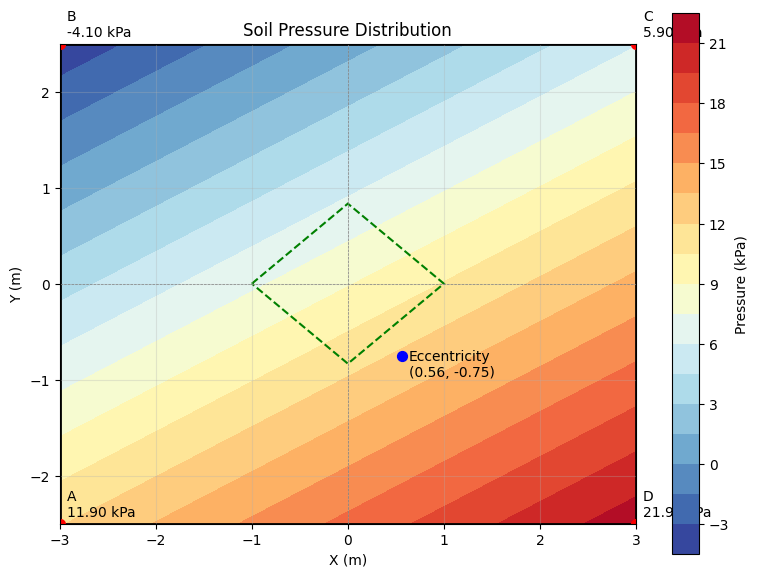

In [25]:
# --- Plotting Footing Pressure Distribution ---

# Create a grid of points
x_grid = np.linspace(-L/2, L/2, 50)
y_grid = np.linspace(-B/2, B/2, 50)
X, Y = np.meshgrid(x_grid, y_grid)

# Calculate pressure at each grid point
Z = np.zeros_like(X)
for i in range(len(x_grid)):
    for j in range(len(y_grid)):
        Z[j,i] = N/(B*L) - (Mx * Y[j,i])/I_x + (My * X[j,i])/I_y

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu_r')
plt.colorbar(contour, label='Pressure (kPa)')

# Plot footing outline
footing = plt.Rectangle((-L/2, -B/2), L, B, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(footing)

# Plot corners with pressure values
for corner, (x, y) in corners.items():
    ax.scatter(x, y, color='red', s=50)
    ax.annotate(f'{corner}\n{pressures[corner]:.2f} kPa', 
                (x, y), xytext=(5, 5), textcoords='offset points')
    
# Plot eccentricity point
ax.scatter(ex, ey, color='blue', s=50, label='Eccentricity Point')
ax.annotate(f'Eccentricity\n({ex:.2f}, {ey:.2f})', 
            (ex, ey), xytext=(5, -15), textcoords='offset points')

# Plot crosshairs at the center
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)  

# Plot Eccentricty region 
eccentricity_region = plt.Polygon([(-L/6, 0), (0, B/6), (L/6, 0), (0, -B/6)], 
                                  fill=False, edgecolor='green', linestyle='--', linewidth=1.5, label='Eccentricity Region')
ax.add_patch(eccentricity_region)

# Labels and title
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Soil Pressure Distribution')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()